# Análisis Exploratorio de Datos - MIDAGRI Perú

**Proyecto ETL**: Pipeline de datos del Ministerio de Desarrollo Agrario y Riego

Este notebook presenta un análisis exploratorio inicial de los datos de producción agrícola
del Perú, incluyendo distribución por departamento, patrones estacionales y relación entre
rendimiento y superficie cosechada.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

# Configuración de estilo profesional (tema oscuro)
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({
    'figure.facecolor': '#1a1a2e',
    'axes.facecolor': '#16213e',
    'text.color': '#e0e0e0',
    'axes.labelcolor': '#e0e0e0',
    'xtick.color': '#b0b0b0',
    'ytick.color': '#b0b0b0',
    'axes.edgecolor': '#333355',
    'grid.color': '#2a2a4a',
    'grid.alpha': 0.5,
    'font.size': 12,
    'axes.titlesize': 16,
    'axes.labelsize': 13,
})

colors = plt.cm.tab10.colors
np.random.seed(42)
print('Librerías cargadas correctamente')

Librerías cargadas correctamente


## 1. Producción Agrícola por Departamento - Top 10

Visualización de los departamentos con mayor producción agrícola total en toneladas.
Los datos reflejan la concentración de la producción en la costa norte y centro del país.


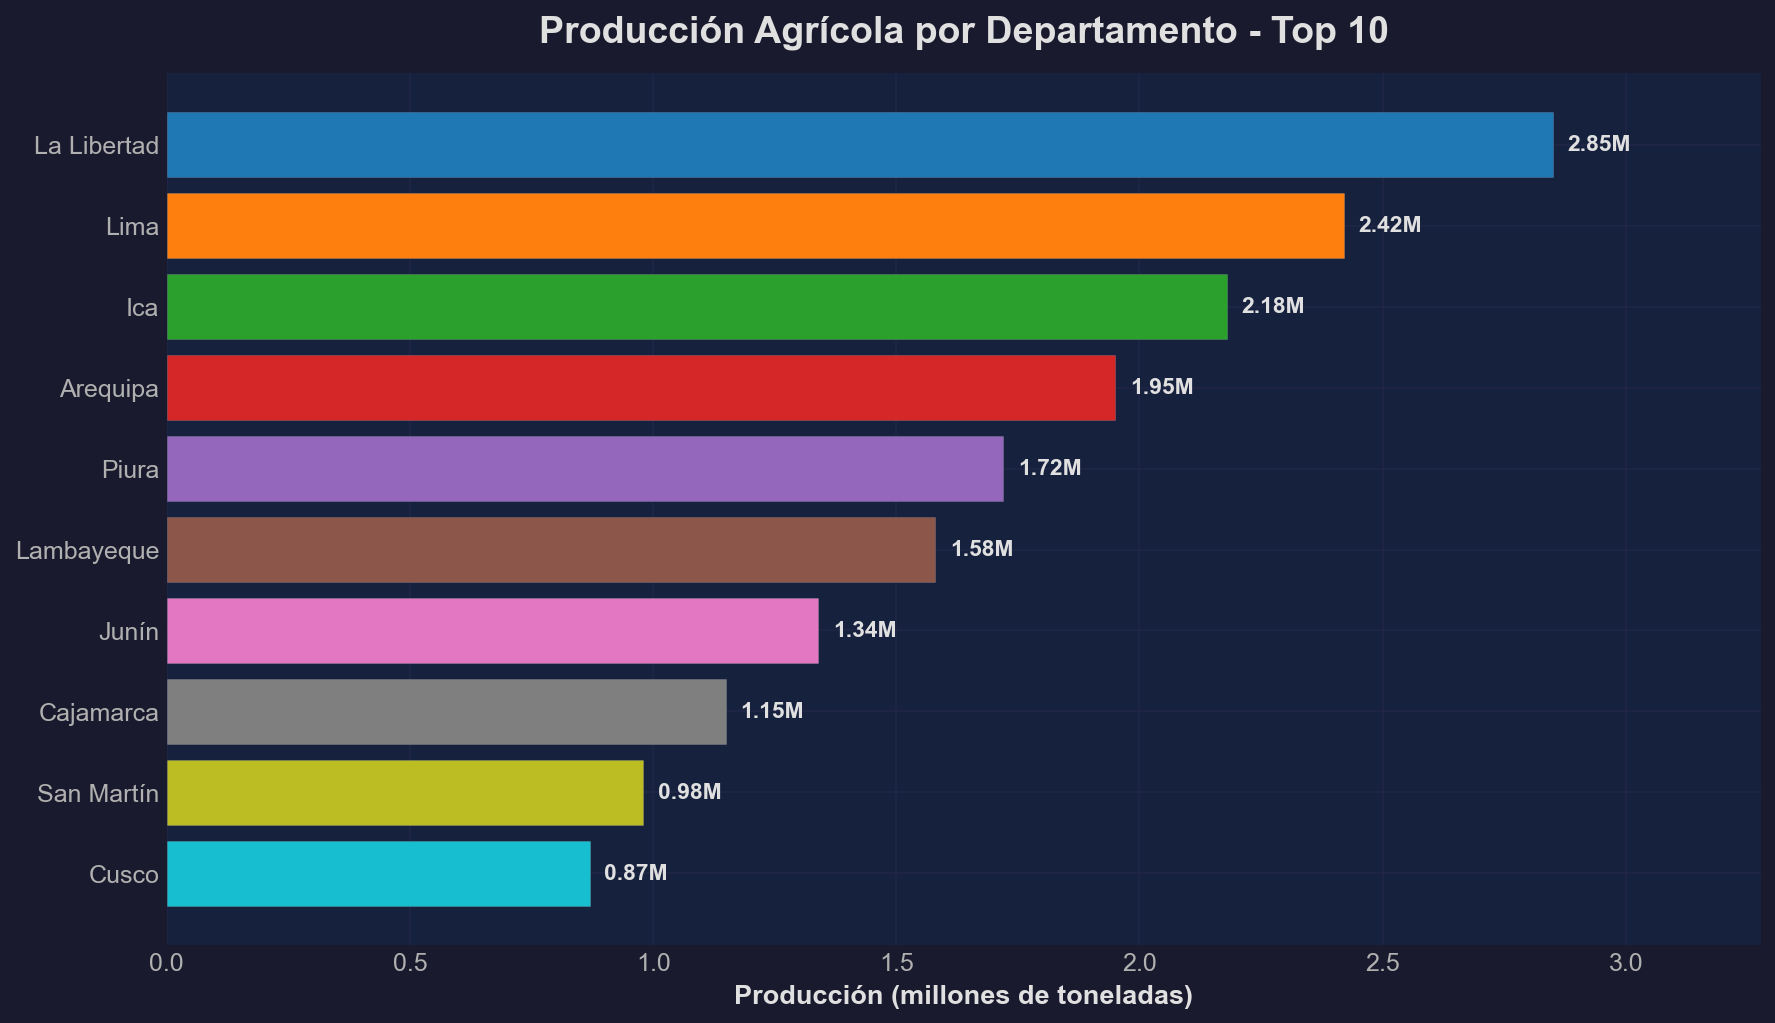

In [2]:
departamentos = ['La Libertad', 'Lima', 'Ica', 'Arequipa', 'Piura',
                 'Lambayeque', 'Junín', 'Cajamarca', 'San Martín', 'Cusco']
produccion = [2_850_000, 2_420_000, 2_180_000, 1_950_000, 1_720_000,
              1_580_000, 1_340_000, 1_150_000, 980_000, 870_000]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(departamentos[::-1], [p/1e6 for p in produccion[::-1]],
               color=[colors[i] for i in range(10)][::-1],
               edgecolor='#ffffff22', linewidth=0.5)

ax.set_xlabel('Producción (millones de toneladas)', fontweight='bold')
ax.set_title('Producción Agrícola por Departamento - Top 10',
             fontweight='bold', fontsize=18, pad=15)

for bar, val in zip(bars, [p/1e6 for p in produccion[::-1]]):
    ax.text(bar.get_width() + 0.03, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}M', va='center', fontsize=11,
            color='#e0e0e0', fontweight='bold')

ax.set_xlim(0, max(produccion)/1e6 * 1.15)
fig.tight_layout()
plt.show()

## 2. Estacionalidad de la Producción Agrícola Mensual

Patrones estacionales de los principales cultivos del Perú. Se observan picos
diferenciados: el arroz alcanza su máxima producción entre marzo y mayo, mientras
que la papa concentra su cosecha entre junio y agosto.


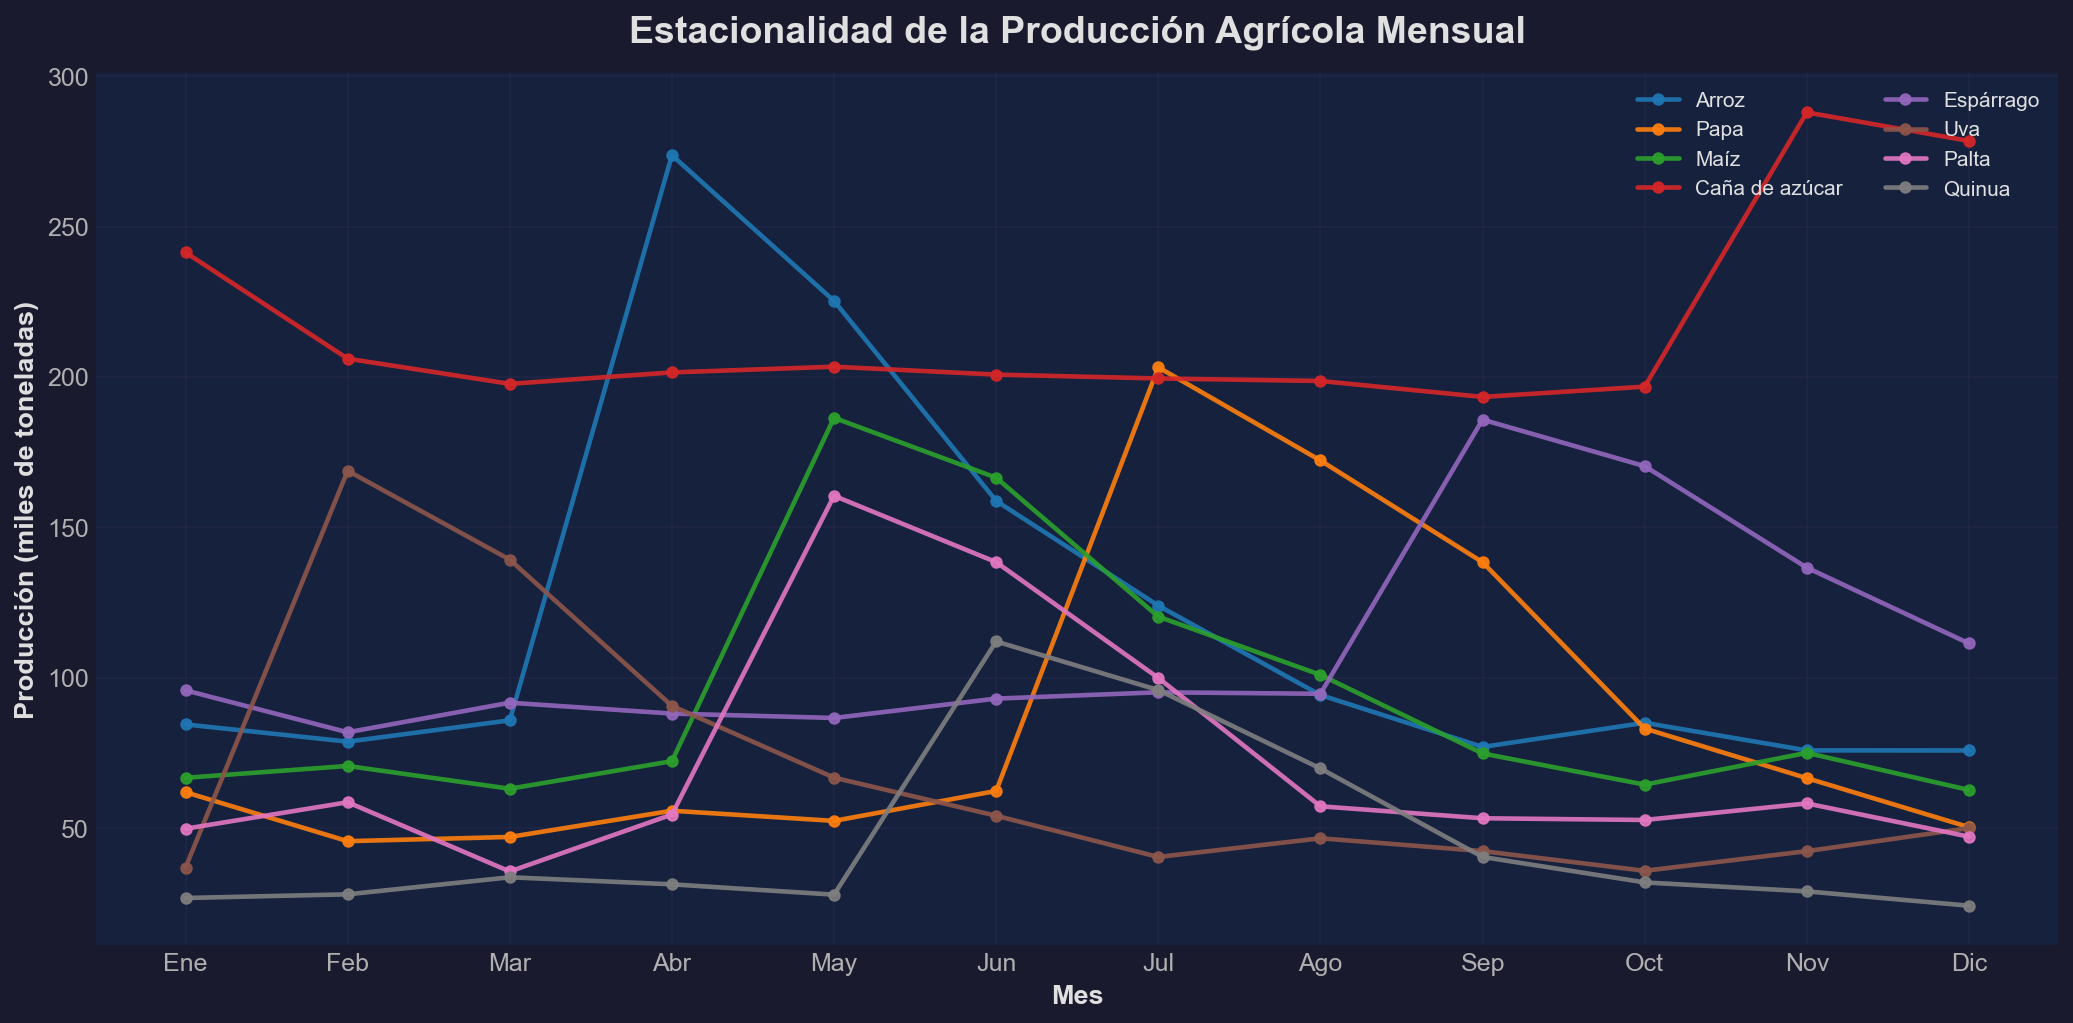

In [3]:
meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
         'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
x = np.arange(12)

def patron_estacional(mes_pico, amplitud, base, ruido=0.05):
    """Genera un patrón estacional gaussiano con envolvente circular."""
    curvas = [base + amplitud * np.exp(-0.5 * ((x - mes_pico + d) % 12) ** 2 / 2.5)
              for d in [0, 12, -12]]
    resultado = np.maximum.reduce(curvas)
    resultado += np.random.normal(0, ruido * amplitud, 12)
    return np.maximum(resultado, base * 0.5)

cultivos = {
    'Arroz':           patron_estacional(3, 180, 80),
    'Papa':            patron_estacional(6, 150, 60),
    'Maíz':            patron_estacional(4, 120, 70),
    'Caña de azúcar':  patron_estacional(10, 90, 200),
    'Espárrago':       patron_estacional(8, 100, 90),
    'Uva':             patron_estacional(1, 130, 40),
    'Palta':           patron_estacional(4, 110, 50),
    'Quinua':          patron_estacional(5, 80, 30),
}

fig, ax = plt.subplots(figsize=(14, 7))
for i, (cultivo, valores) in enumerate(cultivos.items()):
    ax.plot(meses, valores, marker='o', markersize=5, linewidth=2.2,
            color=colors[i], label=cultivo, alpha=0.9)

ax.set_xlabel('Mes', fontweight='bold')
ax.set_ylabel('Producción (miles de toneladas)', fontweight='bold')
ax.set_title('Estacionalidad de la Producción Agrícola Mensual',
             fontweight='bold', fontsize=18, pad=15)
ax.legend(loc='upper right', framealpha=0.8, facecolor='#1a1a2e',
          edgecolor='#444', fontsize=10, ncol=2)
fig.tight_layout()
plt.show()

## 3. Rendimiento por Hectárea vs Superficie Cosechada

Relación entre la superficie cosechada y el rendimiento agrícola por departamento,
segmentado por región natural (Costa, Sierra, Selva). El tamaño de cada punto
representa el volumen total de producción.


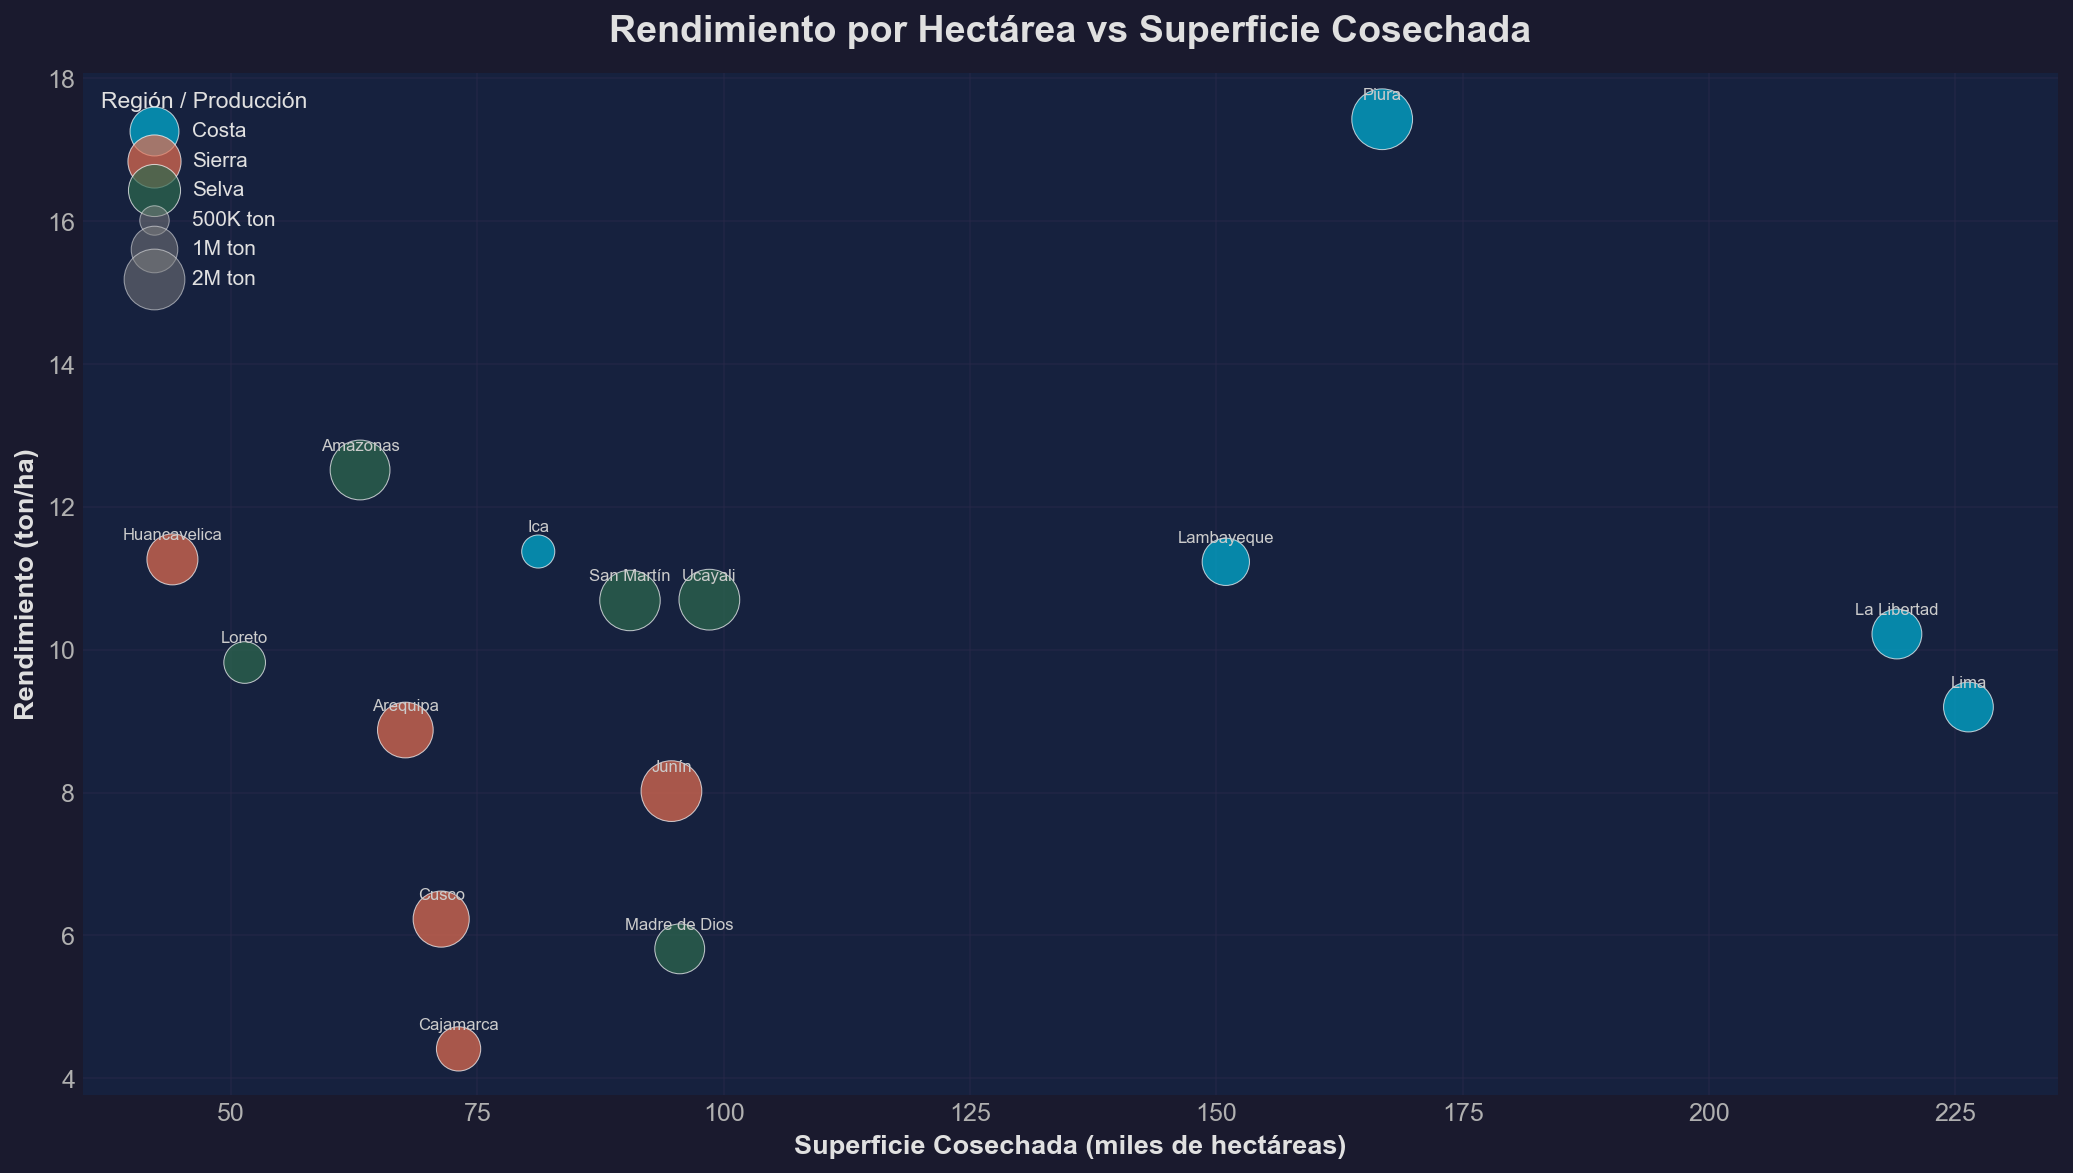

In [4]:
regiones = {
    'Costa': ['La Libertad', 'Lima', 'Ica', 'Piura', 'Lambayeque'],
    'Sierra': ['Arequipa', 'Junín', 'Cajamarca', 'Cusco', 'Huancavelica'],
    'Selva': ['San Martín', 'Ucayali', 'Loreto', 'Madre de Dios', 'Amazonas']
}
region_colors = {'Costa': '#00b4d8', 'Sierra': '#e76f51', 'Selva': '#2d6a4f'}

fig, ax = plt.subplots(figsize=(14, 8))

for region, deptos in regiones.items():
    n = len(deptos)
    if region == 'Costa':
        superficie = np.random.uniform(80_000, 250_000, n)
        rendimiento = np.random.uniform(8, 18, n)
    elif region == 'Sierra':
        superficie = np.random.uniform(40_000, 150_000, n)
        rendimiento = np.random.uniform(4, 12, n)
    else:
        superficie = np.random.uniform(30_000, 120_000, n)
        rendimiento = np.random.uniform(5, 14, n)

    produccion_total = superficie * rendimiento * np.random.uniform(0.7, 1.2, n)
    sizes = (produccion_total / produccion_total.max()) * 800 + 50

    ax.scatter(superficie / 1000, rendimiento, s=sizes,
              c=region_colors[region], alpha=0.7, edgecolors='white',
              linewidth=0.5, label=region, zorder=3)

    for j, depto in enumerate(deptos):
        ax.annotate(depto, (superficie[j]/1000, rendimiento[j]),
                    fontsize=8, color='#cccccc', ha='center', va='bottom',
                    xytext=(0, 8), textcoords='offset points')

ax.set_xlabel('Superficie Cosechada (miles de hectáreas)', fontweight='bold')
ax.set_ylabel('Rendimiento (ton/ha)', fontweight='bold')
ax.set_title('Rendimiento por Hectárea vs Superficie Cosechada',
             fontweight='bold', fontsize=18, pad=15)

# Leyenda combinada: regiones + tamaños de referencia
for size_val, label in [(200, '500K ton'), (500, '1M ton'), (850, '2M ton')]:
    ax.scatter([], [], s=size_val, c='gray', alpha=0.5,
              edgecolors='white', linewidth=0.5, label=label)

legend = ax.legend(loc='upper left', framealpha=0.8, facecolor='#1a1a2e',
                   edgecolor='#444', fontsize=10,
                   title='Región / Producción', title_fontsize=11)
legend.get_title().set_color('#e0e0e0')

fig.tight_layout()
plt.show()

## Conclusiones Preliminares

1. **Concentración geográfica**: La Libertad, Lima e Ica concentran la mayor producción agrícola del país, representando más del 40% del total nacional.

2. **Estacionalidad marcada**: Cada cultivo presenta un patrón estacional diferenciado. El arroz y la uva tienen picos en los primeros meses del año, mientras que la papa y la quinua se concentran en el segundo trimestre.

3. **Eficiencia regional**: Los departamentos de la Costa muestran mayor rendimiento por hectárea y superficies cosechadas más amplias, mientras que la Sierra presenta rendimientos menores pero con potencial de mejora tecnológica.

---
*Datos generados para análisis exploratorio. Fuente de referencia: MIDAGRI - Series Históricas de Producción Agrícola.*
